<a href="https://colab.research.google.com/github/ThumulaRumesh/Smart-Homes---Indoor-Scene-Recognition-from-Images---CNN/blob/develop/03_Data_Preprocessing_%26_Augmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1  — Load the split dataset and inspect sample images

Step 2  — Display one sample from each class

Step 3  — Check image sizes and colour mode

Step 4  — Load the initial train/validation/test datasets

Step 5  — Verify image and label shapes

Step 6  — Check the label values

Step 7  — Verify the resulting resized images


Step 8  — Pixel Scaling / Model-Specific Preprocessing

Step 9  — Data Augmentation

          └── Visualize the augmentation


Step 10 — Create the balanced 500-image training dataset

Step 11 — Create the balanced dataset folders

Step 12 — Balance the training classes

Step 13 — Verify the balanced training set

Step 14 — Copy validation and test unchanged

Step 15 — Verify all three datasets

Step 16 — Reload the balanced train/validation/test datasets

Step 17 — Optimize the Dataset Pipeline

Step 1 - Load the split dataset and inspect sample images

In [1]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf

# Dataset location
dataset_dir = "/content/drive/MyDrive/Colab Notebooks/Y 02 S 02, Advance ML/Assignment/Selected Classes"

# Selected classes
classes = [
    "kitchen",
    "bedroom",
    "casino",
    "warehouse",
    "inside_subway"
]

# Dataset splits
splits = ["train", "validation", "test"]

print("Dataset exists:", os.path.exists(dataset_dir))

Dataset exists: True


Step 2 — Display one sample from each class

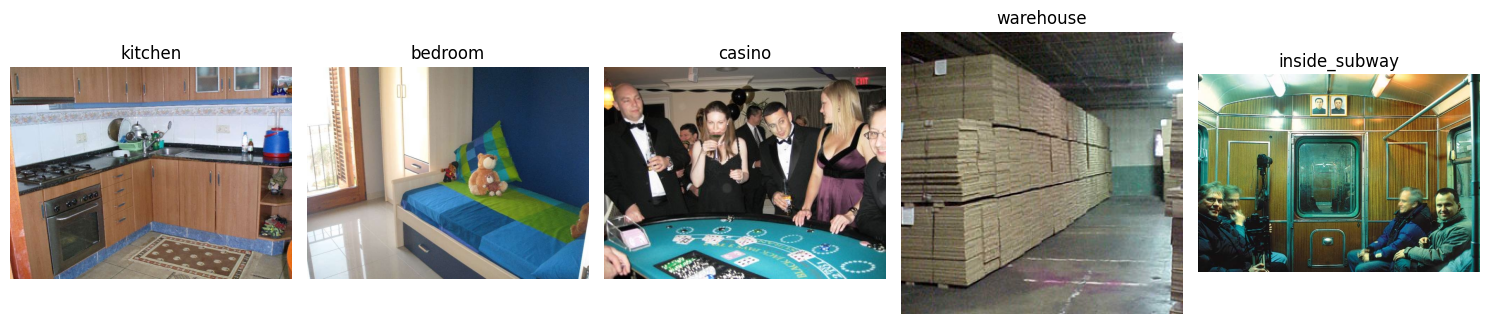

In [2]:
#kitchen > find training folder > get image filenames > select one image > open image > display image
plt.figure(figsize=(15, 8))

for i, class_name in enumerate(classes):

    class_path = os.path.join(dataset_dir, "train", class_name)

    images = [
        file for file in os.listdir(class_path)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    image_path = os.path.join(class_path, images[0])

    image = Image.open(image_path)

    plt.subplot(1, 5, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

Step 3 — Check image sizes and colour mode

In [3]:
for class_name in classes:

    class_path = os.path.join(dataset_dir, "train", class_name)

    images = [
        file for file in os.listdir(class_path)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    image_path = os.path.join(class_path, images[0])
    image = Image.open(image_path)

    print(
        f"{class_name:15} | "
        f"Size: {image.size} | "
        f"Mode: {image.mode}"
    )

kitchen         | Size: (798, 598) | Mode: RGB
bedroom         | Size: (798, 598) | Mode: RGB
casino          | Size: (400, 300) | Mode: RGB
warehouse       | Size: (256, 256) | Mode: RGB
inside_subway   | Size: (700, 490) | Mode: RGB


Step 4 — Load the train, validation and test datasets

In [4]:
#set image size and batch size
image_size = (224, 224) #224 × 224 gives every image the same input size, which is required when images are grouped into batches
batch_size = 32 #Batch size = 32 means the model processes 32 images at a time during training

In [5]:
#Load the three datasets
train_dir = os.path.join(dataset_dir, "train")
validation_dir = os.path.join(dataset_dir, "validation")
test_dir = os.path.join(dataset_dir, "test")

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    class_names=classes,
    color_mode="rgb",
    image_size=image_size,
    batch_size=batch_size,
    shuffle=True,
    seed=42
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    validation_dir,
    labels="inferred", #Labels are taken from the folder names
    label_mode="int", #Classes are represented using integer labels
    class_names=classes,
    color_mode="rgb",
    image_size=image_size,
    batch_size=batch_size,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="int",
    class_names=classes,
    color_mode="rgb",
    image_size=image_size,
    batch_size=batch_size,
    shuffle=False
)

Found 2009 files belonging to 5 classes.
Found 431 files belonging to 5 classes.
Found 434 files belonging to 5 classes.


In [6]:
#Check the dataset output
print("Class names:", train_ds.class_names)

print("Training batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Validation batches:", tf.data.experimental.cardinality(validation_ds).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_ds).numpy())

Class names: ['kitchen', 'bedroom', 'casino', 'warehouse', 'inside_subway']
Training batches: 63
Validation batches: 14
Test batches: 14


Step 5 — Verify image and label shapes

In [7]:
for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Image data type:", images.dtype)
    print("Label data type:", labels.dtype)

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Image data type: <dtype: 'float32'>
Label data type: <dtype: 'int32'>


Step 6 — Check the label values

In [8]:
for images, labels in train_ds.take(1):
    print("Labels:", labels.numpy())

Labels: [2 0 1 3 4 1 2 4 2 0 2 3 0 1 1 3 3 0 1 4 0 4 2 0 0 4 2 3 2 0 2 0]


Step 7 — Verify the resulting resized images

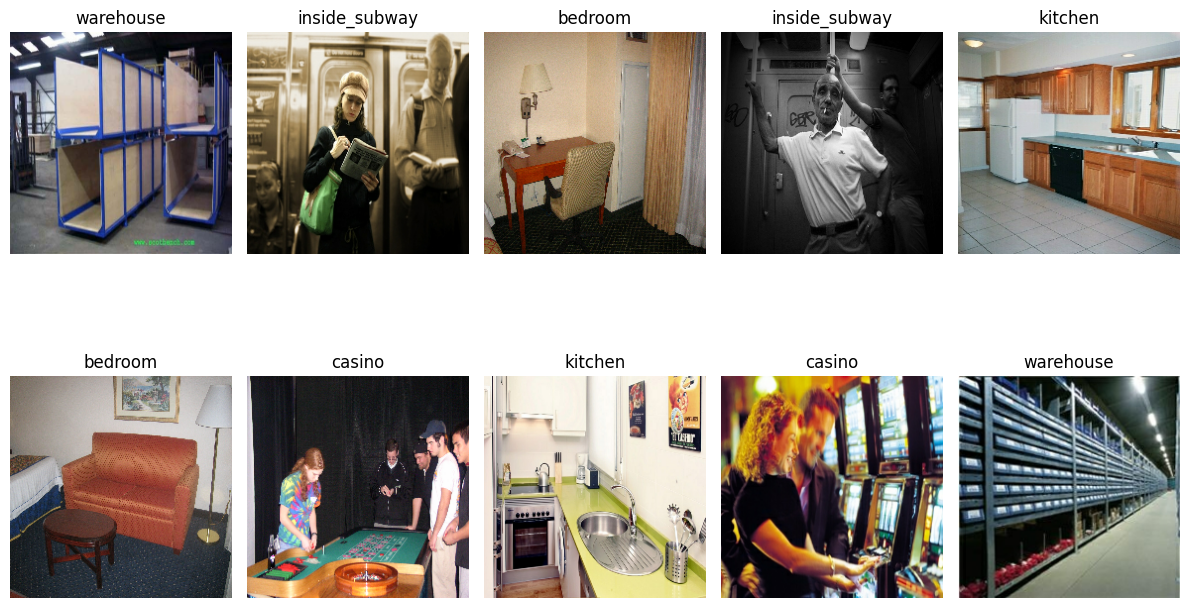

In [9]:
plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):

    for i in range(10):

        plt.subplot(2, 5, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(classes[labels[i].numpy()])

        plt.axis("off")

plt.tight_layout()
plt.show()

Step 8 — Pixel Scaling / Model-Specific Preprocessing

In [10]:
#check the current pixel range
for images, labels in train_ds.take(1):
    print("Minimum pixel value:", tf.reduce_min(images).numpy())
    print("Maximum pixel value:", tf.reduce_max(images).numpy())

Minimum pixel value: 0.0
Maximum pixel value: 255.0


Step 9 — Data Augmentation

In [11]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1)
], name="data_augmentation")

print("Data augmentation pipeline created.")

Data augmentation pipeline created.


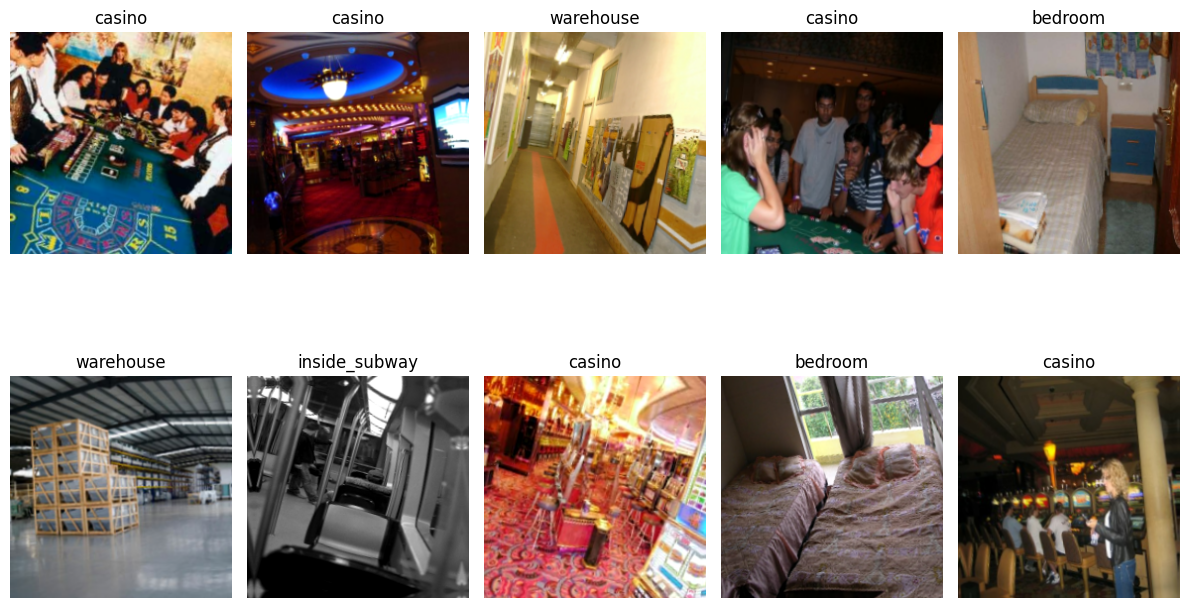

In [12]:
#Visualize the Augmentation
plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):
    augmented_images = data_augmentation(images, training=True)

    for i in range(10):
        plt.subplot(2, 5, i + 1)
        plt.imshow(augmented_images[i].numpy().astype("uint8"))
        plt.title(classes[labels[i].numpy()])
        plt.axis("off")

plt.tight_layout()
plt.show()

Step 10 — Create the balanced 500-image training dataset

In [13]:
import shutil
import numpy as np

source_train_dir = os.path.join(dataset_dir, "train")

balanced_dataset_dir = "/content/drive/MyDrive/Colab Notebooks/Y 02 S 02, Advance ML/Assignment/Selected Classes 500"

balanced_train_dir = os.path.join(balanced_dataset_dir, "train")
balanced_validation_dir = os.path.join(balanced_dataset_dir, "validation")
balanced_test_dir = os.path.join(balanced_dataset_dir, "test")

target_count = 500

print("Balanced dataset location:")
print(balanced_dataset_dir)

Balanced dataset location:
/content/drive/MyDrive/Colab Notebooks/Y 02 S 02, Advance ML/Assignment/Selected Classes 500


Step 11 — Create the folders

In [14]:
for class_name in classes:
    os.makedirs(
        os.path.join(balanced_train_dir, class_name),
        exist_ok=True
    )

    os.makedirs(
        os.path.join(balanced_validation_dir, class_name),
        exist_ok=True
    )

    os.makedirs(
        os.path.join(balanced_test_dir, class_name),
        exist_ok=True
    )

print("Balanced dataset folders created.")

Balanced dataset folders created.


Step 12 — Balance the training classes

In [15]:
import random

random.seed(42)
np.random.seed(42)

for class_name in classes:

    source_class_dir = os.path.join(
        source_train_dir,
        class_name
    )

    target_class_dir = os.path.join(
        balanced_train_dir,
        class_name
    )

    images = [
        file for file in os.listdir(source_class_dir)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    print(f"\n{class_name}")
    print("Original images:", len(images))

    # Case 1: More than 500 images
    if len(images) > target_count:

        selected_images = random.sample(
            images,
            target_count
        )

        for image_name in selected_images:

            source_path = os.path.join(
                source_class_dir,
                image_name
            )

            target_path = os.path.join(
                target_class_dir,
                image_name
            )

            shutil.copy2(
                source_path,
                target_path
            )

    # Case 2: Exactly 500 images
    elif len(images) == target_count:

        for image_name in images:

            source_path = os.path.join(
                source_class_dir,
                image_name
            )

            target_path = os.path.join(
                target_class_dir,
                image_name
            )

            shutil.copy2(
                source_path,
                target_path
            )

    # Case 3: Less than 500 images
    else:

        # First copy all original images
        for image_name in images:

            source_path = os.path.join(
                source_class_dir,
                image_name
            )

            target_path = os.path.join(
                target_class_dir,
                image_name
            )

            shutil.copy2(
                source_path,
                target_path
            )

        # Number of augmented images required
        additional_images = target_count - len(images)

        for i in range(additional_images):

            # Randomly select an original training image
            image_name = random.choice(images)

            source_path = os.path.join(
                source_class_dir,
                image_name
            )

            image = Image.open(source_path).convert("RGB")

            # Convert image to TensorFlow tensor
            image_tensor = tf.convert_to_tensor(
                np.array(image),
                dtype=tf.float32
            )

            # Add batch dimension
            image_tensor = tf.expand_dims(
                image_tensor,
                axis=0
            )

            # Apply random augmentation
            augmented_image = data_augmentation(
                image_tensor,
                training=True
            )

            # Remove batch dimension
            augmented_image = tf.squeeze(
                augmented_image,
                axis=0
            )

            # Convert back to uint8
            augmented_image = tf.clip_by_value(
                augmented_image,
                0,
                255
            )

            augmented_image = tf.cast(
                augmented_image,
                tf.uint8
            )

            # Create new filename
            new_filename = f"augmented_{i:04d}.jpg"

            target_path = os.path.join(
                target_class_dir,
                new_filename
            )

            # Save augmented image
            tf.keras.utils.save_img(
                target_path,
                augmented_image
            )

    # Check final count
    final_count = len([
        file for file in os.listdir(target_class_dir)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

    print("Final images:", final_count)


kitchen
Original images: 513
Final images: 500

bedroom
Original images: 463
Final images: 500

casino
Original images: 360
Final images: 500

warehouse
Original images: 354
Final images: 500

inside_subway
Original images: 319
Final images: 500


Step 13 — Verify the balanced training set

In [16]:
print("BALANCED TRAINING DATASET")

total = 0

for class_name in classes:

    class_dir = os.path.join(
        balanced_train_dir,
        class_name
    )

    count = len([
        file for file in os.listdir(class_dir)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

    total += count

    print(f"{class_name:15} : {count}")

print(f"\nTotal training images: {total}")

BALANCED TRAINING DATASET
kitchen         : 500
bedroom         : 500
casino          : 500
warehouse       : 500
inside_subway   : 500

Total training images: 2500


Step 14 — Copy validation and test unchanged

In [17]:
original_validation_dir = os.path.join(
    dataset_dir,
    "validation"
)

original_test_dir = os.path.join(
    dataset_dir,
    "test"
)

for class_name in classes:

    # Copy validation
    source_validation = os.path.join(
        original_validation_dir,
        class_name
    )

    target_validation = os.path.join(
        balanced_validation_dir,
        class_name
    )

    for image_name in os.listdir(source_validation):

        if image_name.lower().endswith(
            (".jpg", ".jpeg", ".png")
        ):

            shutil.copy2(
                os.path.join(source_validation, image_name),
                os.path.join(target_validation, image_name)
            )

    # Copy test
    source_test = os.path.join(
        original_test_dir,
        class_name
    )

    target_test = os.path.join(
        balanced_test_dir,
        class_name
    )

    for image_name in os.listdir(source_test):

        if image_name.lower().endswith(
            (".jpg", ".jpeg", ".png")
        ):

            shutil.copy2(
                os.path.join(source_test, image_name),
                os.path.join(target_test, image_name)
            )

print("Validation and test datasets copied unchanged.")

Validation and test datasets copied unchanged.


Step 15 — Verify all three datasets

In [18]:
for split, split_dir in [
    ("Train", balanced_train_dir),
    ("Validation", balanced_validation_dir),
    ("Test", balanced_test_dir)
]:

    print(f"\n{split.upper()}")

    total = 0

    for class_name in classes:

        class_dir = os.path.join(
            split_dir,
            class_name
        )

        count = len([
            file for file in os.listdir(class_dir)
            if file.lower().endswith(
                (".jpg", ".jpeg", ".png")
            )
        ])

        total += count

        print(f"{class_name:15} : {count}")

    print("Total:", total)


TRAIN
kitchen         : 500
bedroom         : 500
casino          : 500
warehouse       : 500
inside_subway   : 500
Total: 2500

VALIDATION
kitchen         : 110
bedroom         : 99
casino          : 77
warehouse       : 76
inside_subway   : 69
Total: 431

TEST
kitchen         : 111
bedroom         : 100
casino          : 78
warehouse       : 76
inside_subway   : 69
Total: 434


Step 16 — Load the balanced train, validation and test datasets

In [19]:
dataset_dir = balanced_dataset_dir

train_dir = os.path.join(dataset_dir, "train")
validation_dir = os.path.join(dataset_dir, "validation")
test_dir = os.path.join(dataset_dir, "test")

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    class_names=classes,
    color_mode="rgb",
    image_size=image_size,
    batch_size=batch_size,
    shuffle=True,
    seed=42
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    validation_dir,
    labels="inferred",
    label_mode="int",
    class_names=classes,
    color_mode="rgb",
    image_size=image_size,
    batch_size=batch_size,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="int",
    class_names=classes,
    color_mode="rgb",
    image_size=image_size,
    batch_size=batch_size,
    shuffle=False
)

print("Balanced datasets loaded.")

Found 2500 files belonging to 5 classes.
Found 431 files belonging to 5 classes.
Found 434 files belonging to 5 classes.
Balanced datasets loaded.


Step 17 — Optimize the Dataset Pipeline

In [20]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
validation_ds = validation_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

print("Dataset prefetching configured.")

Dataset prefetching configured.
